**STEP-1: Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from PIL import Image

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from  tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet import preprocess_input

In [4]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)

In [5]:
from sklearn.preprocessing import label_binarize
import json

In [6]:
import warnings 
warnings.filterwarnings("ignore")

**STEP-2: Data Importation**

In [7]:
train_dir="C:\\Brain MRI Dataset\\Training"
test_dir="C:\\Brain MRI Dataset\\Testing"

In [8]:
train_dir

'C:\\Brain MRI Dataset\\Training'

In [9]:
test_dir

'C:\\Brain MRI Dataset\\Testing'

In [10]:
class_names=sorted(os.listdir(train_dir))
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [11]:
#Count Images per class
for split_name, split_dir in [("Training", train_dir), ("Testing", test_dir)]:
    print(f"\n{split_name} set:")
    total = 0
    for cls in class_names:
        cls_path = os.path.join(split_dir, cls)
        count = len(os.listdir(cls_path))
        total += count
        print(f"  {cls}: {count} images")
    print(f"  TOTAL: {total} images")
    


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  TOTAL: 5600 images

Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  TOTAL: 1600 images


**STEP-3: Label Distribution Chart**

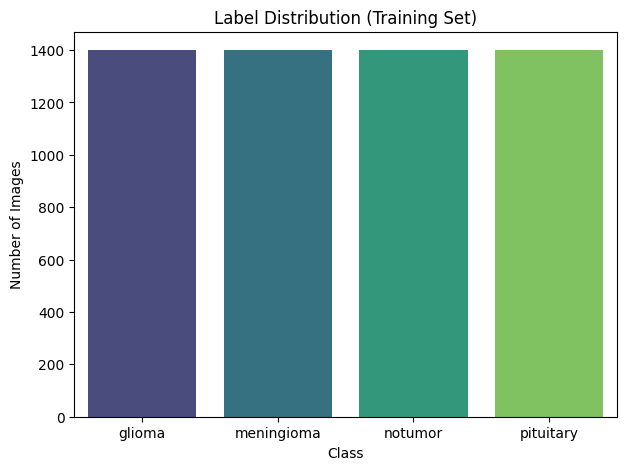

In [12]:
counts={cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
plt.figure(figsize=(7,5))
sns.barplot(x=list(counts.keys()),
           y=list(counts.values()),
           palette="viridis")
plt.title("Label Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

**STEP-4: Display 5 of Sample Images**

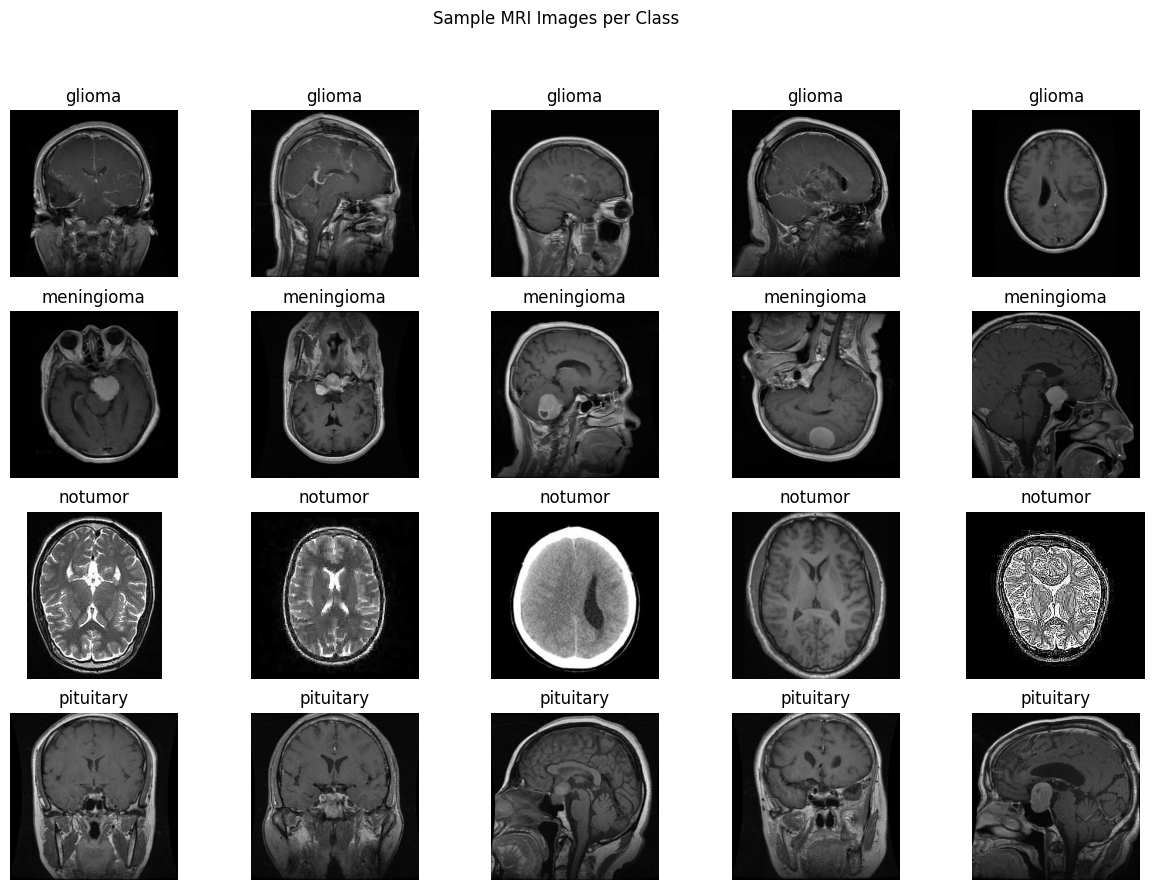

In [13]:
images_per_class=5
plt.figure(figsize=(15,10))
sample_count=0
for cls in class_names:
    cls_path=os.path.join(train_dir,cls)
    sample_imgs=os.listdir(cls_path)[:images_per_class]

    for sample_img in sample_imgs:
        img=plt.imread(os.path.join(cls_path,sample_img))
                   

        sample_count+=1
        plt.subplot(len(class_names), images_per_class, sample_count)
        plt.imshow(img,cmap="gray")
        plt.title(cls)
        plt.axis("off")

plt.suptitle("Sample MRI Images per Class")
plt.show()

**STEP5: Train/Validation Split + Data Generation**

In [14]:
IMG_SIZE=(224,224)
BATCH_SIZE=32

#Training Generation
train_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [15]:
test_datagen=ImageDataGenerator(preprocessing_function=preprocess_input)
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 4760 images belonging to 4 classes.


In [16]:
val_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

Found 840 images belonging to 4 classes.


In [17]:
test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [18]:
print("Class Indices:", train_generator.class_indices)


Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### **Model Building**
**STEP-6: EfficientNetB0 transfer learning mode**

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import json

In [21]:
num_classes=len(class_names)

base_model=EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3),
)

In [22]:
#Freeze base model initially
base_model.trainable=False
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
x=Dense(128,activation="relu")(x)
x=Dropout(0.2)(x)
output=Dense(num_classes,activation="softmax")(x)

In [23]:
model=Model(inputs=base_model.input,outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**STEP-7: Training the Model**

In [24]:
early_stop=EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [25]:
reduce_lr=ReduceLROnPlateau(
    monitor="val_loss",factor=0.5, restore_best_weights=True
)

In [26]:
history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.6090 - auc: 0.8422 - loss: 0.9658 - val_accuracy: 0.7810 - val_auc: 0.9463 - val_loss: 0.6171 - learning_rate: 1.0000e-04
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7649 - auc: 0.9367 - loss: 0.6279 - val_accuracy: 0.8369 - val_auc: 0.9656 - val_loss: 0.4736 - learning_rate: 1.0000e-04
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 839s 6s/step - accuracy: 0.7947 - auc: 0.9535 - loss: 0.5304 - val_accuracy: 0.8440 - val_auc: 0.9710 - val_loss: 0.4207 - learning_rate: 1.0000e-04
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.8155 - auc: 0.9612 - loss: 0.4788 - val_accuracy: 0.8560 - val_auc: 0.9732 - val_loss: 0.3967 - learning_rate: 1.0000e-04
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 675s 5s/step - accuracy: 0.8359 - auc: 0.9666 - loss: 0.4420 - val_accuracy: 0.8702 - val_auc: 0.9758 - val_loss: 0.3722 - learning_rate: 1.0000e-04
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - 

**STEP-8: Fine-tune the base ,mmodel**

In [30]:
base_model.trainable=True

In [31]:
for layer in base_model.layers[:-20]:
    layer.trainable=False

In [33]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy",tf.keras.metrics.AUC(name="auc")]
)

In [43]:
fine_tune_history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8567 - auc: 0.9731 - loss: 0.4299 - val_accuracy: 0.8917 - val_auc: 0.9834 - val_loss: 0.3221 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.8624 - auc: 0.9772 - loss: 0.3842 - val_accuracy: 0.8952 - val_auc: 0.9844 - val_loss: 0.3101 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.8824 - auc: 0.9824 - loss: 0.3402 - val_accuracy: 0.8952 - val_auc: 0.9859 - val_loss: 0.2902 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8832 - auc: 0.9827 - loss: 0.3248 - val_accuracy: 0.9012 - val_auc: 0.9865 - val_loss: 0.2831 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 399s 3s/step - accuracy: 0.8905 - auc: 0.9839 - loss: 0.3128 - val_accuracy: 0.8976 - val_auc: 0.9866 - val_loss: 0.2761 - learning_rate: 1.0000e-05


**STEP-9: Combine training History**

In [44]:
def combine_histories(h1,h2):
    combined={}
    for key in h1.history:
        combined[key]=h1.history[key]+h2.history[key]
    return combined
full_history=combine_histories(history, fine_tune_history)

**STEP-10: Training & Validation**

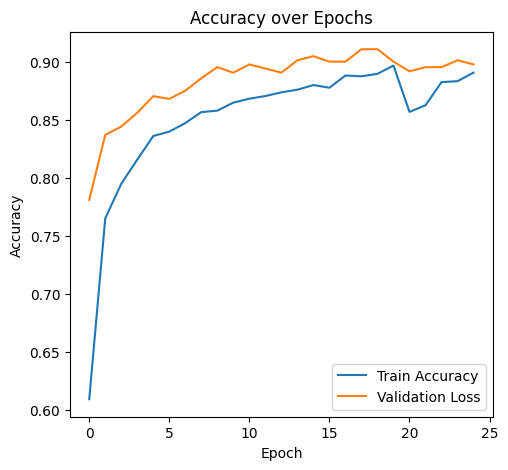

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(full_history["accuracy"],label="Train Accuracy")
plt.plot(full_history["val_accuracy"],label="Validation Loss")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

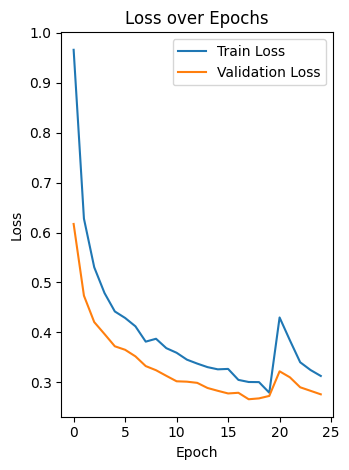

In [46]:
plt.subplot(1,2,2)
plt.plot(full_history["loss"],label="Train Loss")
plt.plot(full_history["val_loss"],label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**STEP-11: Run Predictions on the Test Set**

In [47]:
test_generator.reset()
y_pred_probs=model.predict(test_generator)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=test_generator.classes
class_labels=list(test_generator.class_indices.keys())

50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 886ms/step


**STEP-12: Accuracy, Precision, Recall, and F1-Score**

In [48]:
print(classification_report(y_true,y_pred,target_names=class_labels))

              precision    recall  f1-score   support

      glioma       0.88      0.65      0.75       400
  meningioma       0.79      0.66      0.72       400
     notumor       0.82      0.99      0.90       400
   pituitary       0.80      0.98      0.88       400

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.81      1600
weighted avg       0.82      0.82      0.81      1600



**STEP-13: Confusion Matrix**

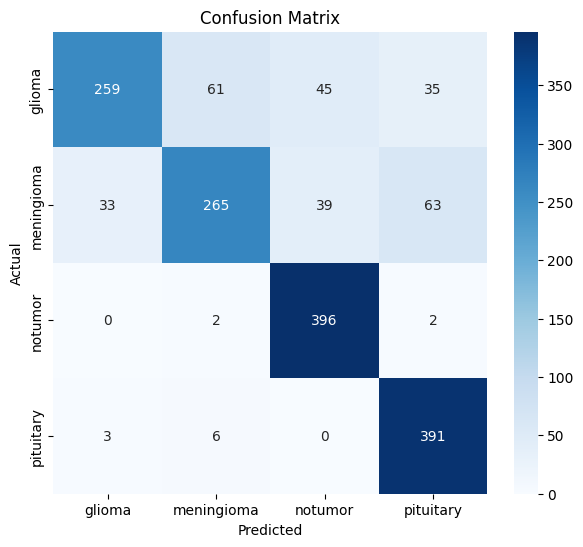

In [49]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**STEP-14: ROC and AUC Curve Graphs**

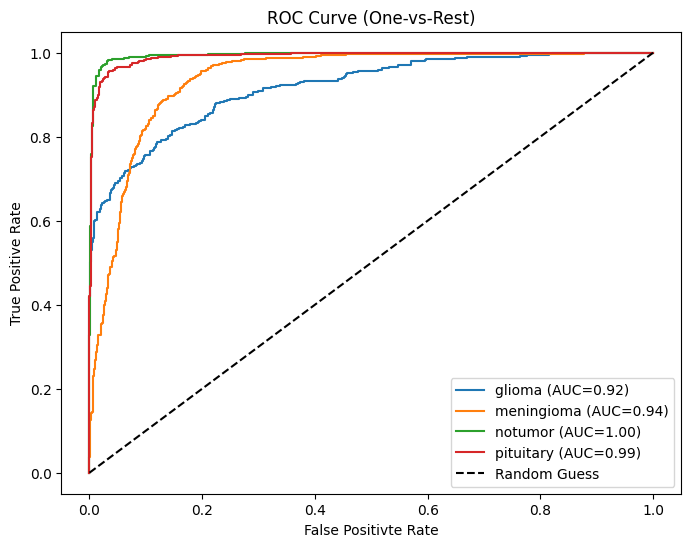

In [53]:
y_true_bin=label_binarize(y_true,classes=range(num_classes))
plt.figure(figsize=(8,6))
for i, cls in enumerate(class_labels):
    fpr,tpr,_=roc_curve(y_true_bin[:,i],y_pred_probs[:,i])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--",label="Random Guess")
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positivte Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
    

**STEP-15: Save the Model**

In [54]:
model.save("Brain_Tumor_Model.keras")

with open("class_names.json","w") as f:
    json.dump(class_labels,f)
print("Model and class names saves successfully.")

Model and class names saves successfully.
